<a href="https://colab.research.google.com/github/Subho7439/cnn_cat_dog_identification/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import tensorflow
import pandas as pd
x_train = pd.read_csv("input.csv",delimiter=",")
y_train = pd.read_csv("labels.csv",delimiter=",")
x_test = pd.read_csv("input_test.csv",delimiter=",")
y_test = pd.read_csv("labels_test.csv",delimiter=",")



In [15]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1999, 30000)
(1999, 1)
(399, 30000)
(399, 1)


In [16]:
x_train = x_train.to_numpy()
y_train = y_train.to_numpy()
x_test = x_test.to_numpy()
y_test = y_test.to_numpy()

In [17]:
x_train = x_train.reshape(len(x_train),100,100,3)
x_test = x_test.reshape(len(x_test),100,100,3)
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

In [18]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1999, 100, 100, 3)
(1999, 1)
(399, 100, 100, 3)
(399, 1)


In [19]:
x_train = x_train/255.0

x_test = x_test/255.0


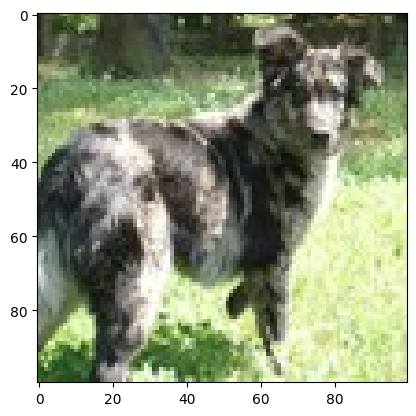

In [20]:
import random
import matplotlib.pyplot as plt
idx = random.randint(0,len(x_train))
plt.imshow(x_train[idx,:])
plt.show()

In [21]:
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization
from keras.models import Sequential

cnn = Sequential()
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)))
cnn.add(MaxPooling2D((2,2)))
cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPooling2D((2,2)))
cnn.add(Flatten())
cnn.add(Dense(64,activation='relu'))
cnn.add(BatchNormalization())
cnn.add(Dense(1,activation='sigmoid'))

cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


cnn.fit(x_train,y_train,epochs=5,batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 477ms/step - accuracy: 0.5908 - loss: 0.7029
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 467ms/step - accuracy: 0.7209 - loss: 0.5558
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 459ms/step - accuracy: 0.7974 - loss: 0.4470
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 457ms/step - accuracy: 0.8674 - loss: 0.3192
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 457ms/step - accuracy: 0.9030 - loss: 0.2464


In [22]:
cnn.evaluate(x_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.6140 - loss: 0.6396


[0.6396009922027588, 0.6140350699424744]

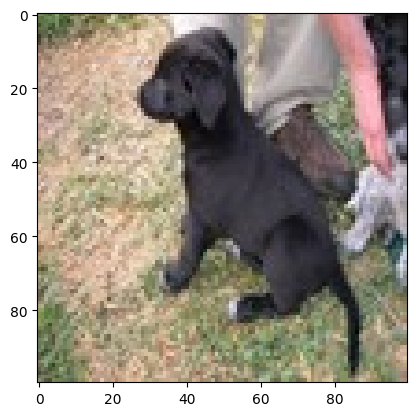

In [23]:
import random
import matplotlib.pyplot as plt
idx1 = random.randint(0,len(x_test))
plt.imshow(x_test[idx1,:])
plt.show()

In [24]:
predict = cnn.predict(x_test[idx1,:].reshape(1,100,100,3))
print(predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
[[0.5013224]]


In [25]:
if predict > 0.5:
    print("Dog")
else:
    print("Cat")

Dog
